# **Projeto de Ciência de Dados: Análise e Previsão de Anomalias de Temperatura Global**

## **Situação Negócio/Problema**

A análise e previsão de anomalias de temperatura global são cruciais para entender as mudanças climáticas e seus impactos. Este projeto visa desenvolver um modelo de série temporal capaz de prever futuras anomalias de temperatura, identificando padrões de longo prazo (tendência), variações sazonais e eventos extremos. A capacidade de prever essas anomalias pode auxiliar na tomada de decisões estratégicas em setores como agricultura, saúde pública e planejamento urbano, bem como na formulação de políticas ambientais eficazes para mitigar os efeitos das mudanças climáticas.

## **1. Importação das Bibliotecas**

In [125]:
!pip install -q pmdarima
!pip install -q prophet

In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import (mean_absolute_error, mean_squared_error, mean_absolute_percentage_error)
from pmdarima import auto_arima
from prophet import Prophet
from prophet.plot import plot_plotly

## **2. Aquisição dos Dados**
- Carregamento dos dados
- Leitura de arquivos, banco de dados ou APIs

In [127]:
# Exemplo: Carregar um dataset de série temporal de exemplo (temperaturas globais)
# Baixar o dataset (se necessário):
# !wget -nc https://raw.githubusercontent.com/datasets/global-temp/main/data/monthly.csv

df = pd.read_csv('https://raw.githubusercontent.com/datasets/global-temp/main/data/monthly.csv')
display(df.head())

,Source,Year,Mean
0,GCAG,1850-01,-0.7337
1,GCAG,1850-02,-0.3604
2,GCAG,1850-03,-0.6271
3,GCAG,1850-04,-0.6053
4,GCAG,1850-05,-0.5315


## **3. Preparação dos Dados**
- Conversão para datetime
- Definição do índice temporal
- Ordenação cronológica
- Definição da frequência (`asfreq`)

In [128]:
# Filtrar apenas uma fonte de dados para evitar duplicatas no índice temporal
df = df[df['Source'] == 'GCAG'].copy()

# Conversão para datetime usando a coluna correta 'Year'
df['Year'] = pd.to_datetime(df['Year'])
df = df.set_index('Year')

# Ordenação cronológica
df = df.sort_index()

# Definição da frequência (MS = Month Start)
df = df.asfreq('MS')

# Limpeza e renomeação
df = df[['Mean']]
df.columns = ['temperatura_media']

display(df.head())
display(df.info())

,temperatura_media
Year,
1850-01-01,-0.7337
1850-02-01,-0.3604
1850-03-01,-0.6271
1850-04-01,-0.6053
1850-05-01,-0.5315


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2115 entries, 1850-01-01 to 2026-03-01
Freq: MS
Data columns (total 1 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   temperatura_media  2115 non-null   float64
dtypes: float64(1)
memory usage: 33.0 KB


None

In [129]:
df.head()

,temperatura_media
Year,
1850-01-01,-0.7337
1850-02-01,-0.3604
1850-03-01,-0.6271
1850-04-01,-0.6053
1850-05-01,-0.5315


## **4. Análise Exploratória dos Dados (EDA)**

### **4.1 Estatísticas Descritivas**


In [130]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
temperatura_media,2115.0,-0.058496,0.414238,-1.04,-0.346,-0.1521,0.13195,1.3481


### **4.2 Visualização da Série Temporal**


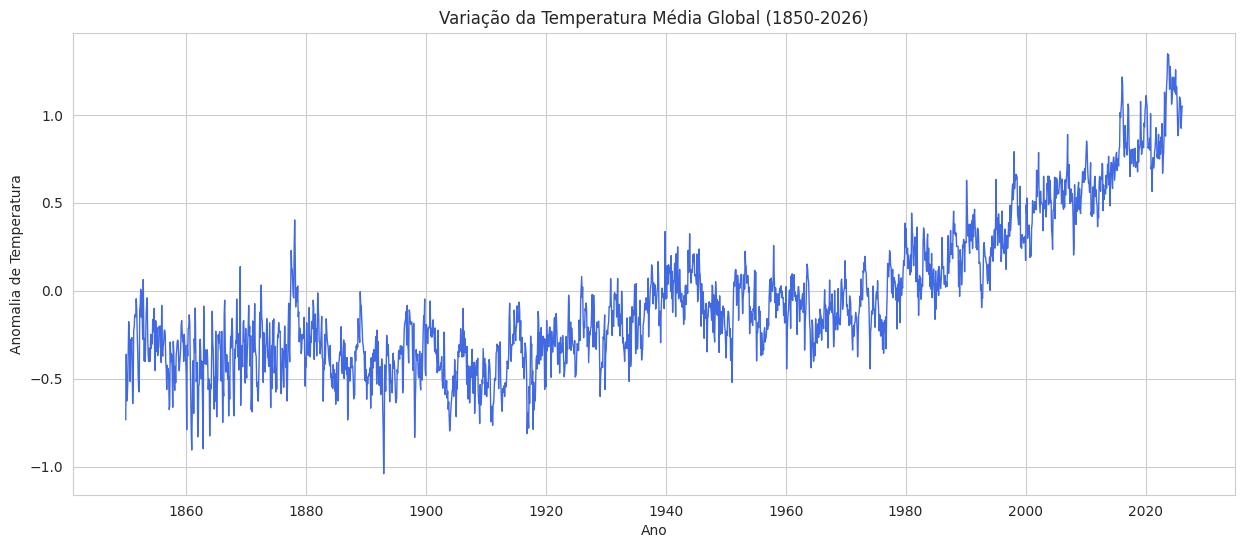

In [131]:
plt.figure(figsize=(15, 6))  # Ajuste o tamanho da figura conforme necessário
plt.plot(df.index, df['temperatura_media'], color='royalblue', linewidth=1)
plt.title('Variação da Temperatura Média Global (1850-2026)')
plt.xlabel('Ano')
plt.ylabel('Anomalia de Temperatura')
plt.grid(True)
plt.show()

### **4.3 Identificação de Tendência**


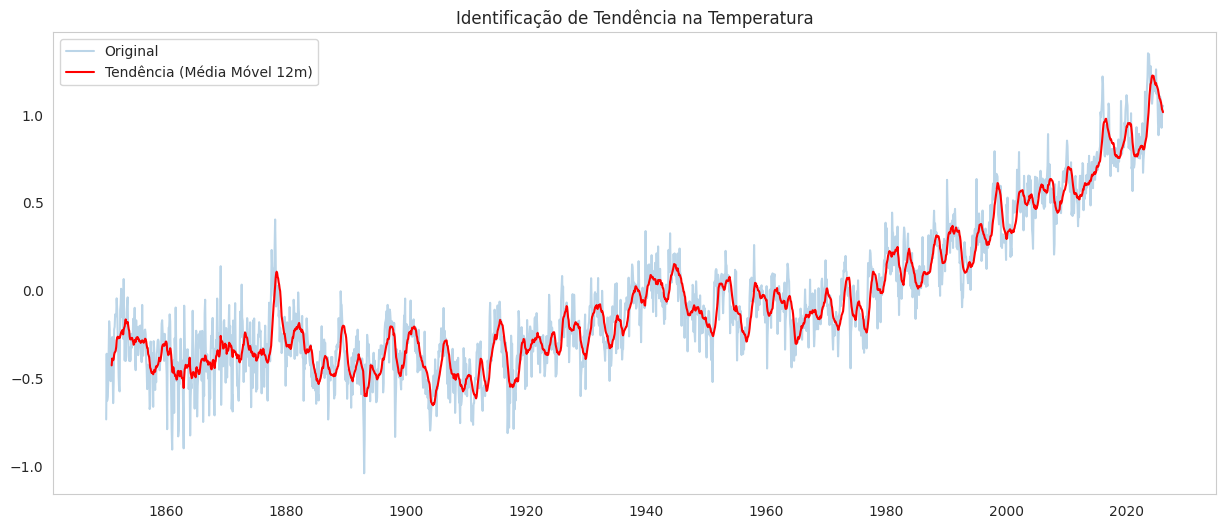

In [132]:
# Média móvel de 12 meses para visualizar tendência suave
df['tendencia_12m'] = df['temperatura_media'].rolling(window=12).mean()

plt.figure(figsize=(15, 6))
plt.plot(df.index, df['temperatura_media'], alpha=0.3, label='Original')
plt.plot(df.index, df['tendencia_12m'], color='red', label='Tendência (Média Móvel 12m)')
plt.title('Identificação de Tendência na Temperatura')
plt.grid()
plt.legend()
plt.show()

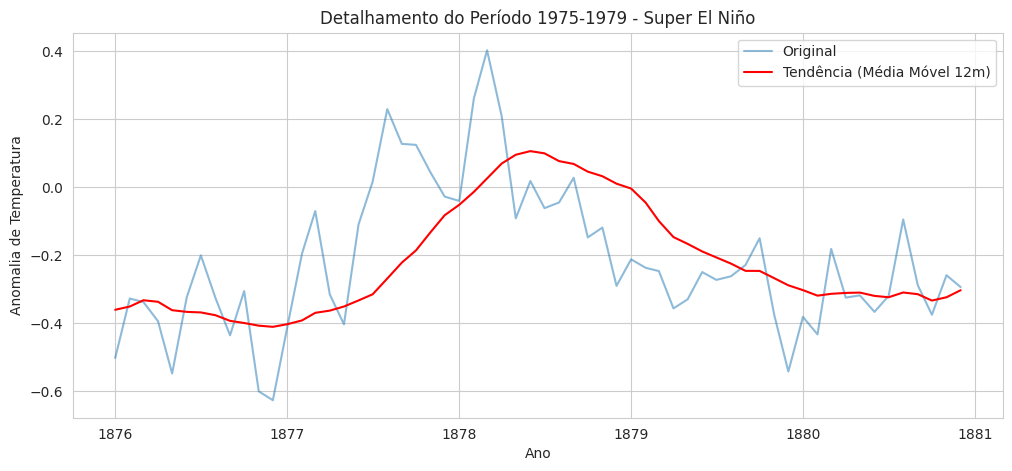

In [133]:
# Definindo o período de interesse
dados_periodo = df.loc['1876-01-01':'1880-12-01']

plt.figure(figsize=(12, 5))
# Agora filtramos tanto o X quanto o Y para o mesmo tamanho
plt.plot(dados_periodo.index, dados_periodo['temperatura_media'], alpha=0.5, label='Original')
plt.plot(dados_periodo.index, dados_periodo['tendencia_12m'], color='red', label='Tendência (Média Móvel 12m)')

plt.title('Detalhamento do Período 1975-1979 - Super El Niño')
plt.xlabel('Ano')
plt.ylabel('Anomalia de Temperatura')
plt.legend()
plt.grid(True)
plt.show()

O pico de temperatura global entre 1877 e 1879 ocorreu devido a um Super El Niño somado ao fenômeno do Dipolo do Oceano Índico. Isso causou secas e fomes extremas em todo o mundo, afetando gravemente o Nordeste brasileiro e dizimando cerca de 4% da população global.  
O El Niño acontece em intervalos irregulares de 2 a 7 anos e dura geralmente de 9 a 12 meses. Ele se desenvolve ao longo do ano, atinge o pico em dezembro e perde força no outono seguinte.

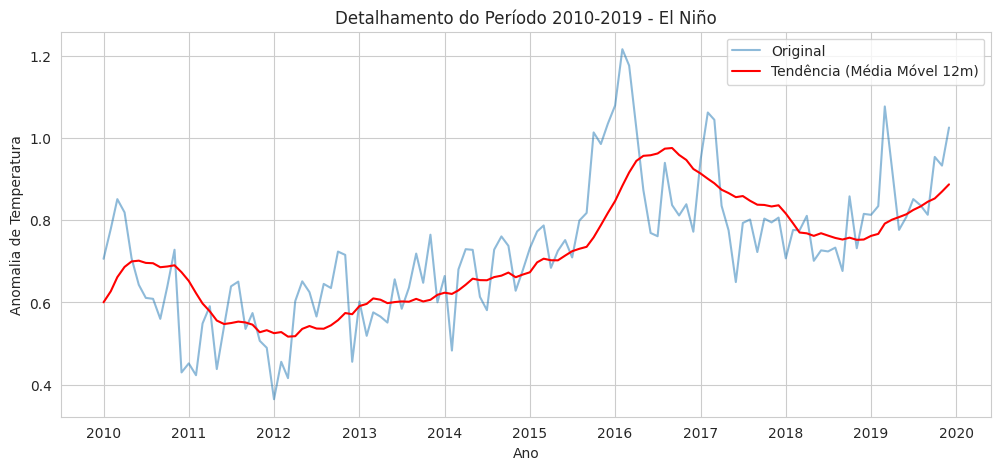

In [134]:
# Definindo o período de interesse
dados_periodo = df.loc['2010-01-01':'2019-12-01']

plt.figure(figsize=(12, 5))
# Agora filtramos tanto o X quanto o Y para o mesmo tamanho
plt.plot(dados_periodo.index, dados_periodo['temperatura_media'], alpha=0.5, label='Original')
plt.plot(dados_periodo.index, dados_periodo['tendencia_12m'], color='red', label='Tendência (Média Móvel 12m)')

plt.title('Detalhamento do Período 2010-2019 - El Niño')
plt.xlabel('Ano')
plt.ylabel('Anomalia de Temperatura')
plt.legend()
plt.grid(True)
plt.show()

Entre 2015 e 2016, a Terra registrou um pico histórico de temperatura. O ano de 2015 quebrou o recorde de ano mais quente, e 2016 superou esse valor, tornando-se um dos anos mais quentes já registrados. Esse pico ocorreu pela soma de dois fatores principais:  
* O Super El Niño: Um dos fenômenos mais intensos já registrados aqueceu as águas do Oceano Pacífico. Esse calor extra foi liberado do oceano para a atmosfera, elevando as temperaturas.
* Aquecimento Global: O efeito estufa causado pelas emissões humanas elevou a temperatura base do planeta. O El Niño funcionou como um "empurrão" extra a um sistema que já estava mais quente.

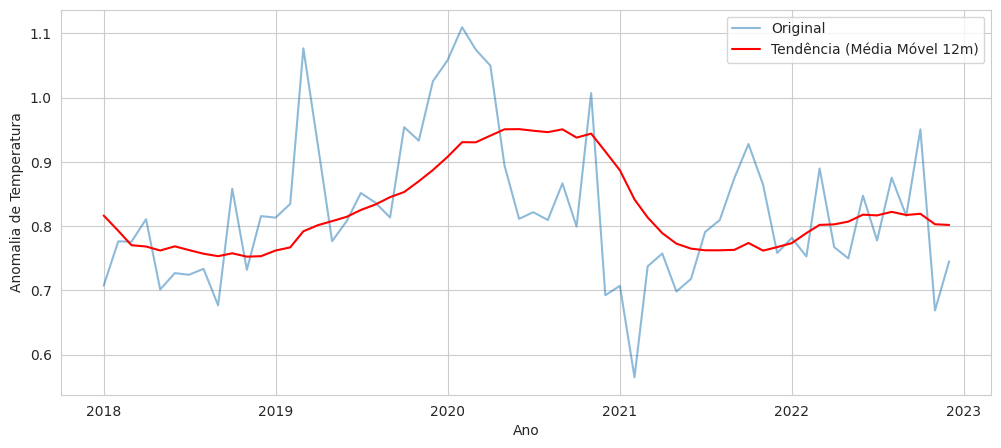

In [135]:
# Definindo o período de interesse
dados_periodo = df.loc['2018-01-01':'2022-12-01']

plt.figure(figsize=(12, 5))
# Agora filtramos tanto o X quanto o Y para o mesmo tamanho
plt.plot(dados_periodo.index, dados_periodo['temperatura_media'], alpha=0.5, label='Original')
plt.plot(dados_periodo.index, dados_periodo['tendencia_12m'], color='red', label='Tendência (Média Móvel 12m)')

#plt.title('Detalhamento do Período 1975-1979 - Super El Niño')
plt.xlabel('Ano')
plt.ylabel('Anomalia de Temperatura')
plt.legend()
plt.grid(True)
plt.show()

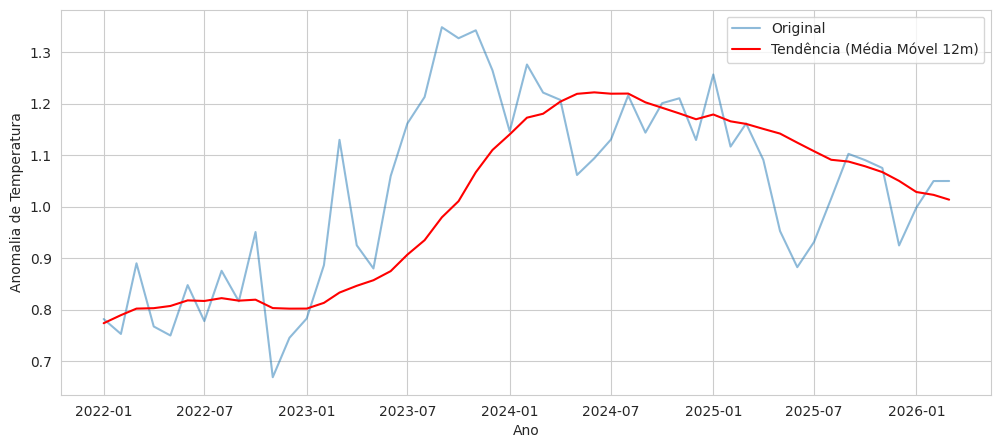

In [136]:
# Definindo o período de interesse
dados_periodo = df.loc['2022-01-01':'2026-12-01']

plt.figure(figsize=(12, 5))
# Agora filtramos tanto o X quanto o Y para o mesmo tamanho
plt.plot(dados_periodo.index, dados_periodo['temperatura_media'], alpha=0.5, label='Original')
plt.plot(dados_periodo.index, dados_periodo['tendencia_12m'], color='red', label='Tendência (Média Móvel 12m)')

#plt.title('Detalhamento do Período 1975-1979 - Super El Niño')
plt.xlabel('Ano')
plt.ylabel('Anomalia de Temperatura')
plt.legend()
plt.grid(True)
plt.show()

2023 foi o ano mais quente da história, com a temperatura média global atingindo cerca de 14,98°C, ou seja, praticamente 1,5°C acima dos níveis pré-industriais. Esse recorde foi confirmado globalmente por organizações meteorológicas de referência, mas já foi superado posteriormente.  
* 2023 (Início do Pico): Teve um aquecimento recorde, impulsionado pelo início de um forte fenômeno El Niño. Fechou com 1,48 °C acima da média pré-industrial.  
* 2024 (O Ápice): O calor do El Niño atingiu o ápice combinado com o aquecimento global. Foi o ano mais quente da história, atingindo 1,62 °C acima da média.
* 2025 (A Queda): O fenômeno El Niño perdeu força e deu lugar à La Niña. Isso causou a queda nos dados, fazendo 2025 recuar para o posto de 3º ano mais quente, ficando marginalmente abaixo de 2023.

### **4.4 Decomposição da Série Temporal** (Identificação de Sazonalidade)


1. **Série Original:** É a sua série como ela foi coletada.  
2. **Tendência (Trend):** Como a série evolui ao longo do tempo, ignorando as oscilações sazonais?
    * Crescente → existe aumento ao longo dos anos.
    * Decrescente → existe queda.
    * Horizontal → não há tendência.
3. **Sazonalidade (Seasonal):** Se esse gráfico se repete regularmente, sua série possui sazonalidade.
4. **Resíduos (Residual):** Depois que o algoritmo remove:
    * tendência
    * sazonalidade

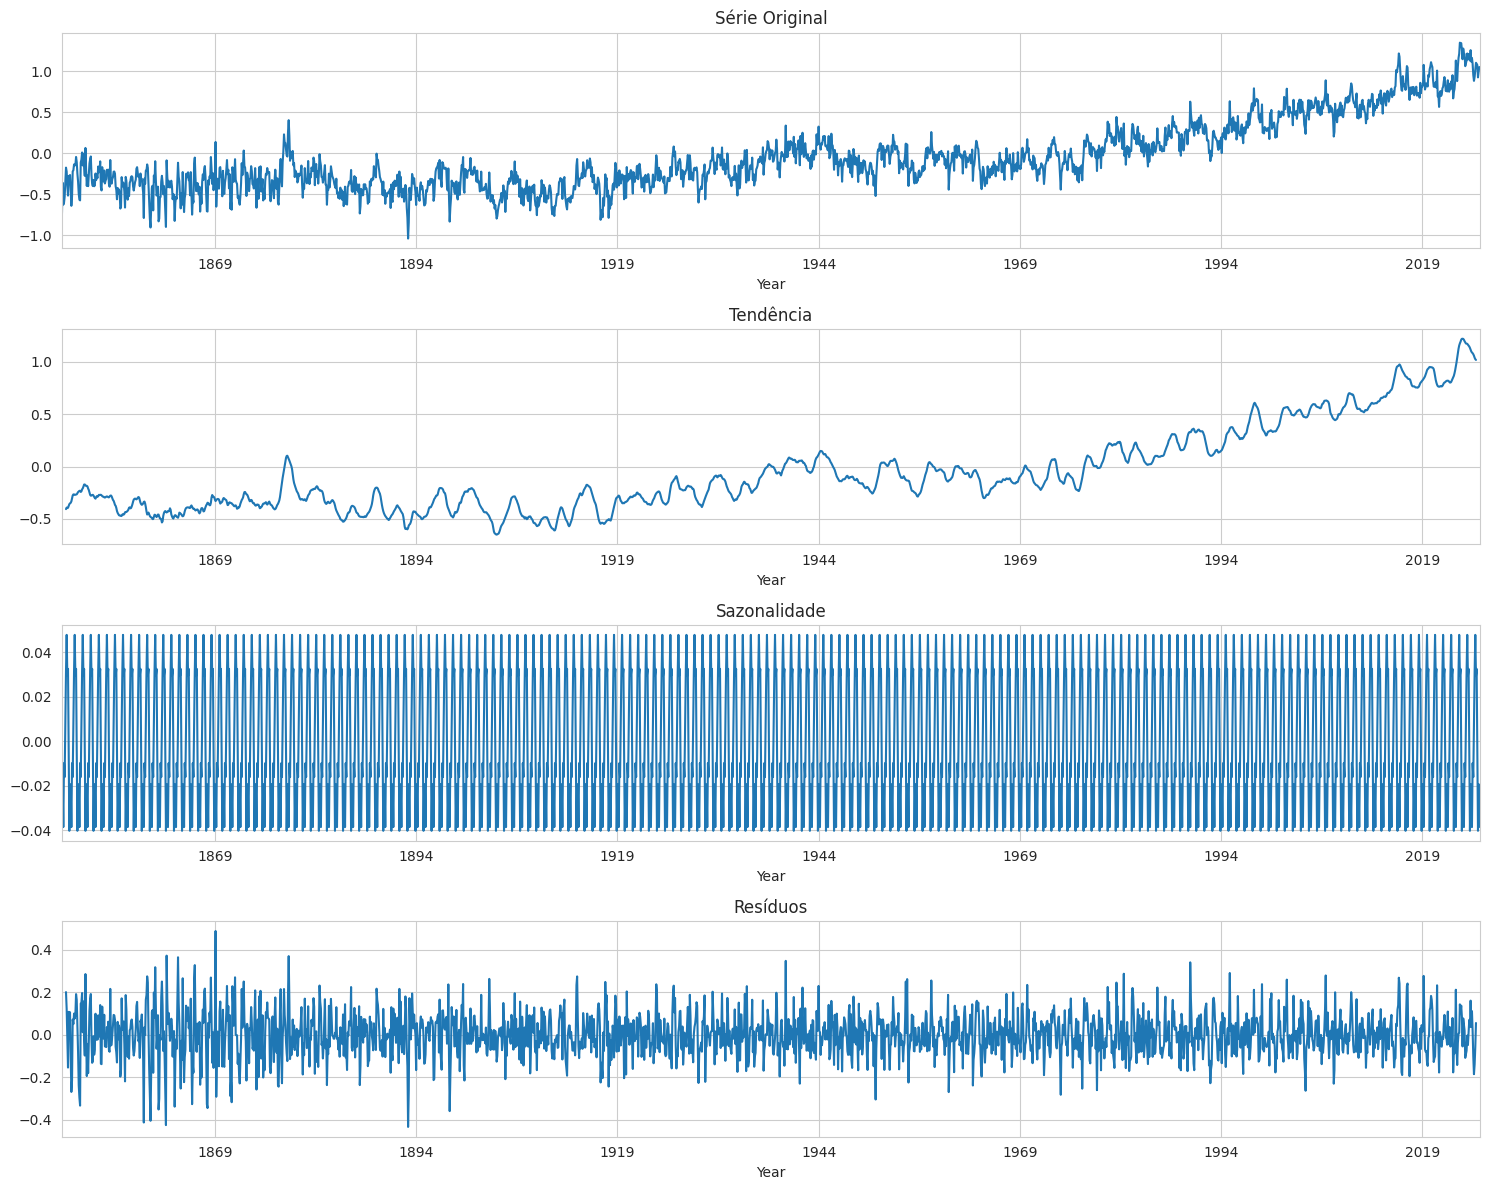

In [137]:
# Decomposição básica para visualização rápida da sazonalidade
fig, ax = plt.subplots(4, 1, figsize=(15, 12))
decomposicao = seasonal_decompose(df['temperatura_media'], model='additive', period=12)

titulos = ['Série Original', 'Tendência', 'Sazonalidade', 'Resíduos']
components = [decomposicao.observed, decomposicao.trend, decomposicao.seasonal, decomposicao.resid]

for i, (component, titulo) in enumerate(zip(components, titulos)):
    component.plot(ax=ax[i])
    ax[i].set_title(titulo)

plt.tight_layout()
plt.show()


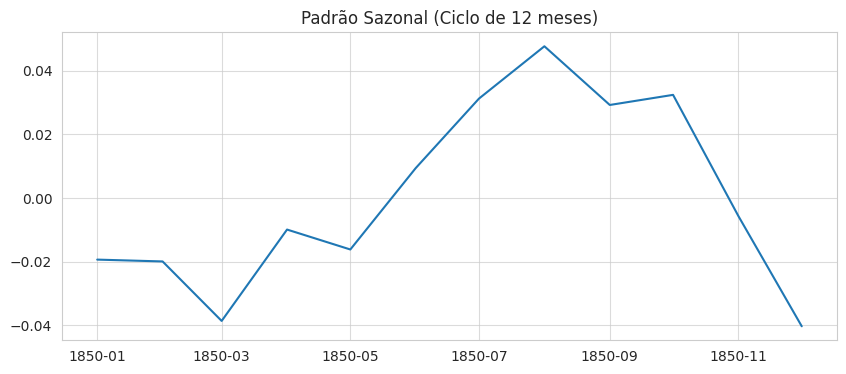

In [138]:
# Acessando os componentes individualmente para análise
tendencia = decomposicao.trend
sazonalidade = decomposicao.seasonal
residuos = decomposicao.resid

# Exemplo: Verificando a sazonalidade no ano de 1850
plt.figure(figsize=(10, 4))
plt.plot(sazonalidade.iloc[:12])
plt.title('Padrão Sazonal (Ciclo de 12 meses)')
plt.grid(True, alpha=0.7)
plt.show()

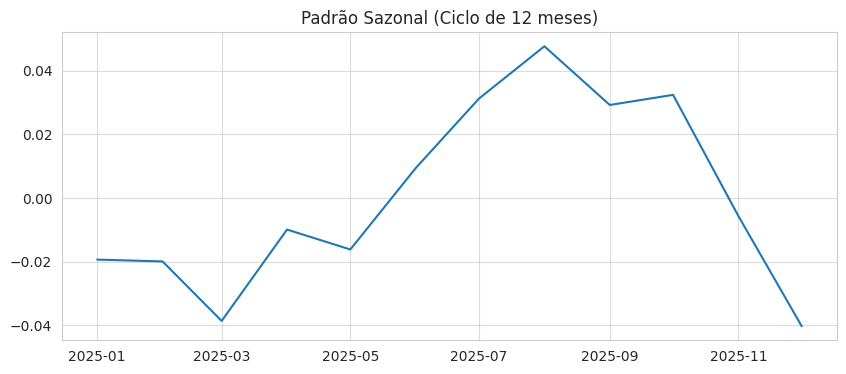

In [139]:
# Exemplo: Verificando a sazonalidade no ano de 2025
plt.figure(figsize=(10, 4))
plt.plot(sazonalidade.iloc[-15:-3])
plt.title('Padrão Sazonal (Ciclo de 12 meses)')
plt.grid(True, alpha=0.7)
plt.show()

### **4.5 Anomalias**

In [140]:
## Index com as anomalias
anomalias = np.where(np.abs(decomposicao.resid) > 2.5 * np.std(decomposicao.resid))
anomalias

(array([  14,   26,   27,   35,  122,  127,  131,  132,  139,  144,  145,
         155,  156,  168,  173,  180,  194,  197,  198,  216,  217,  222,
         229,  230,  251,  253,  258,  338,  516,  517,  578,  637,  768,
        1079, 1213, 1260, 1322, 1489, 1543, 1583, 1682, 1741, 1854, 1884,
        1993, 2030]),)

In [141]:
datas_anomalas = df.iloc[anomalias]['temperatura_media'].sort_values(ascending=False)
print('=='*20)
print("Os cinco primeiras anomalias")
print('=='*20)
display(datas_anomalas.head())
print('')
print('=='*20)
print("As cinco últimas anomalias")
print('=='*20)
display(datas_anomalas.tail().sort_values(ascending=True))
print('=='*20)

Os cinco primeiras anomalias


,temperatura_media
Year,
2016-02-01,1.2161
2019-03-01,1.0769
2007-01-01,0.8886
1995-02-01,0.6332
1990-03-01,0.6284



As cinco últimas anomalias


,temperatura_media
Year,
1893-01-01,-1.0400
1861-01-01,-0.9052
1862-12-01,-0.8983
1893-02-01,-0.8461
1898-03-01,-0.8334


In [142]:
datas_anomalas

,temperatura_media
Year,
2016-02-01,1.2161
2019-03-01,1.0769
2007-01-01,0.8886
1995-02-01,0.6332
1990-03-01,0.6284
1878-03-01,0.4030
1981-12-01,0.3624
1939-12-01,0.3372
2004-07-01,0.2363


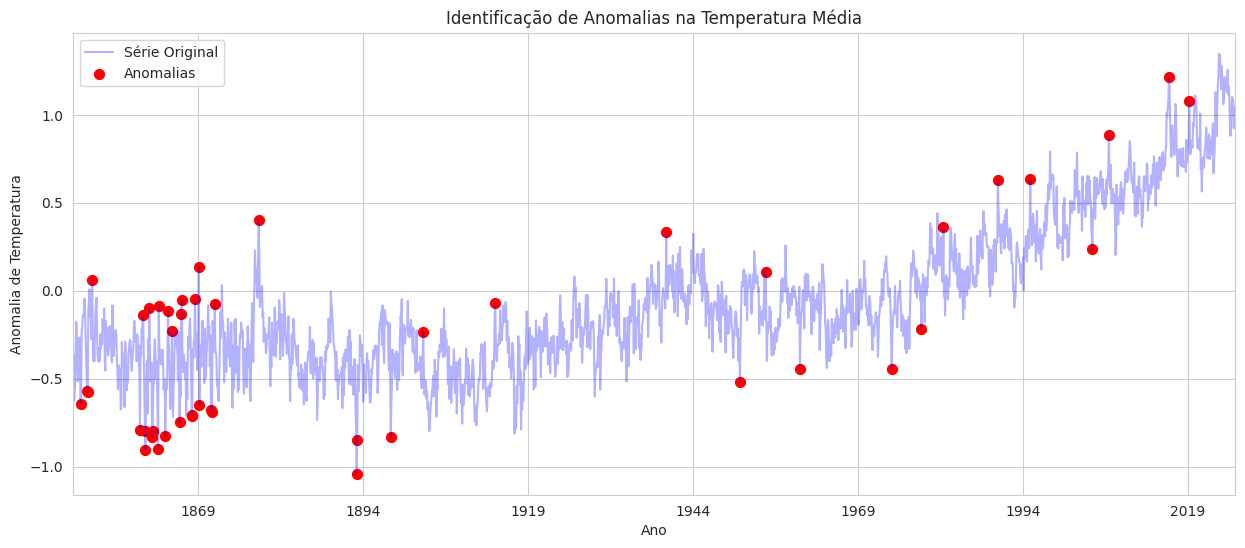

In [143]:
## Plotagem do gráfico com as anomalias ao longo do tempo
fig, ax = plt.subplots(figsize=(15, 6))

sns.set_style('whitegrid')
df['temperatura_media'].plot(alpha=0.3, color='blue', ax=ax, label='Série Original')
ax.scatter(df.iloc[anomalias].index,
           df.iloc[anomalias]['temperatura_media'],
           marker='o',
           color='red',
           s=50,
           label='Anomalias')

ax.set_title('Identificação de Anomalias na Temperatura Média')
ax.set_xlabel('Ano')
ax.set_ylabel('Anomalia de Temperatura')
ax.legend()
plt.show()

**Insight Anomalias:**  
Isso pode indicar:  
* um El Niño forte;
* uma La Niña forte;
* uma grande erupção vulcânica;
* outro evento climático extremo;
* ou, em alguns casos, um erro de medição.

**Algumas Datas:**
* Em 01/02/2016 foi apontado pela agência americana NOAA como o fevereiro mais quente já registrado desde 1880, com temperaturas globais bem acima da média.
* Em 01/03/2019, não houve um fenômeno climático único ou extremo no mundo todo, mas sim o padrão típico de transição entre o verão e o outono. Naquela época, o planeta já estava na tendência de se tornar o segundo ano mais quente da história.




#### **Insight:**  
* A decomposição da série temporal evidencia uma tendência crescente nas anomalias de temperatura ao longo do período de 1850 a 2026, com uma aceleração perceptível a partir da década de 1980. Além disso, observa-se uma sazonalidade anual bem definida, indicando que o comportamento dos meses se repete de forma consistente ao longo dos anos.  
* Os picos identificados na série original provavelmente estão associados a eventos climáticos reais, como El Niño e La Niña, e não necessariamente a erros de medição.  
* Após a remoção da tendência e da sazonalidade, os resíduos não apresentam padrões visuais evidentes, sugerindo que os principais componentes da série foram adequadamente capturados pela decomposição, embora análises adicionais dos resíduos sejam recomendadas para confirmar essa hipótese.

✅ Preferir um modelo que considere sazonalidade, como:

* SARIMA
* SARIMAX (se houver variáveis externas)
* Prophet
* modelos de Machine Learning com variáveis sazonais (mês, trimestre, etc.).

### **4.6 Identificação de Possíveis Outliers**


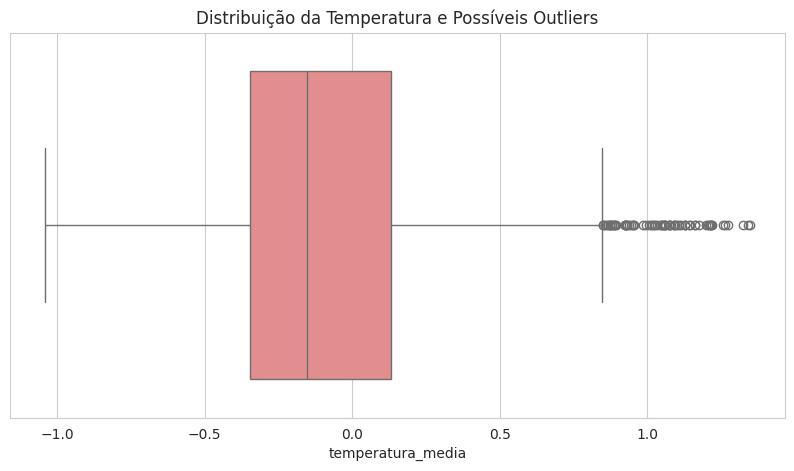

In [144]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['temperatura_media'], color='lightcoral')
plt.title('Distribuição da Temperatura e Possíveis Outliers')
plt.show()

## **5. Tratamento dos Dados**

### **5.1 Tratamento de Valores Ausentes**


In [145]:
print("Valores ausentes por coluna:")
print(df.isnull().sum())

Valores ausentes por coluna:
temperatura_media     0
tendencia_12m        11
dtype: int64


### **5.2 Tratamento de Outliers**

**Insight:**  
Embora a série apresente picos em determinados períodos, esses valores não são considerados erros de medição, mas sim eventos climáticos reais. Portanto, eles foram mantidos na análise para preservar a integridade da série temporal e garantir que o modelo seja capaz de capturar variações extremas que podem influenciar as previsões.

### **5.3 Correção da Frequência Temporal**

In [146]:
print(df.index.freq)

<MonthBegin>


In [147]:
print(pd.infer_freq(df.index))

MS


In [148]:
datas_esperadas = pd.date_range(
    start=df.index.min(),
    end=df.index.max(),
    freq="MS"
)

datas_esperadas.difference(df.index) # não há meses ausentes.

DatetimeIndex([], dtype='datetime64[ns]', freq='MS')

### **5.4 Remoção de Duplicatas**

In [149]:
df.duplicated().sum() ## Não há dados duplicados

np.int64(0)

## **6. Testes Estatísticos**

Agora os testes estatísticos respondem perguntas como:

* A série realmente possui tendência?
* A série é estacionária?
* A sazonalidade é significativa?
* Existe autocorrelação?
* Os resíduos são aleatórios

### **6.1 Teste ADF** (Verificar estacionariedade)

In [150]:
def test_stationarity(timeseries):
    print('Resultado do Teste Dickey-Fuller:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Teste Estatístico', 'p-valor', 'Lags Usados', 'Número de Observações'])
    for key, value in dftest[4].items():
        dfoutput[f'Valor Crítico ({key})'] = value
    print(dfoutput)

test_stationarity(df['temperatura_media'])

Resultado do Teste Dickey-Fuller:
Teste Estatístico          -0.471514
p-valor                     0.897457
Lags Usados                26.000000
Número de Observações    2088.000000
Valor Crítico (1%)         -3.433486
Valor Crítico (5%)         -2.862925
Valor Crítico (10%)        -2.567507
dtype: float64


**Interpretação do teste ADF:**  
O teste de Dickey-Fuller apresentou um p-valor de 0,897, superior ao nível de significância de 5%. Portanto, não foi possível rejeitar a hipótese nula de existência de raiz unitária, indicando que a série temporal não é estacionária. Esse resultado está de acordo com a análise exploratória, que identificou uma tendência crescente nas anomalias de temperatura ao longo do período analisado. Dessa forma, será necessário aplicar técnicas de transformação, como diferenciação, antes da utilização de modelos estatísticos que dependem de estacionariedade, como ARIMA/SARIMA.

### **6.2 Teste KPSS** (Confirmar estacionariedade) - Opcional

### **6.3 Análise de Autocorrelação - ACF/PACF** (Identificar dependência temporal)

ACF e PACF são ferramentas usadas para analisar a dependência temporal da série. Elas ajudam a entender se o valor atual depende dos valores anteriores e são muito importantes para modelos como ARIMA e SARIMA.

In [185]:
df['diff_1'] = df['temperatura_media'].diff(12).shift(1)
df.head()

,temperatura_media,tendencia_12m,diff_1
Year,,,
1850-01-01,-0.7337,NaN,NaN
1850-02-01,-0.3604,NaN,NaN
1850-03-01,-0.6271,NaN,NaN
1850-04-01,-0.6053,NaN,NaN
1850-05-01,-0.5315,NaN,NaN


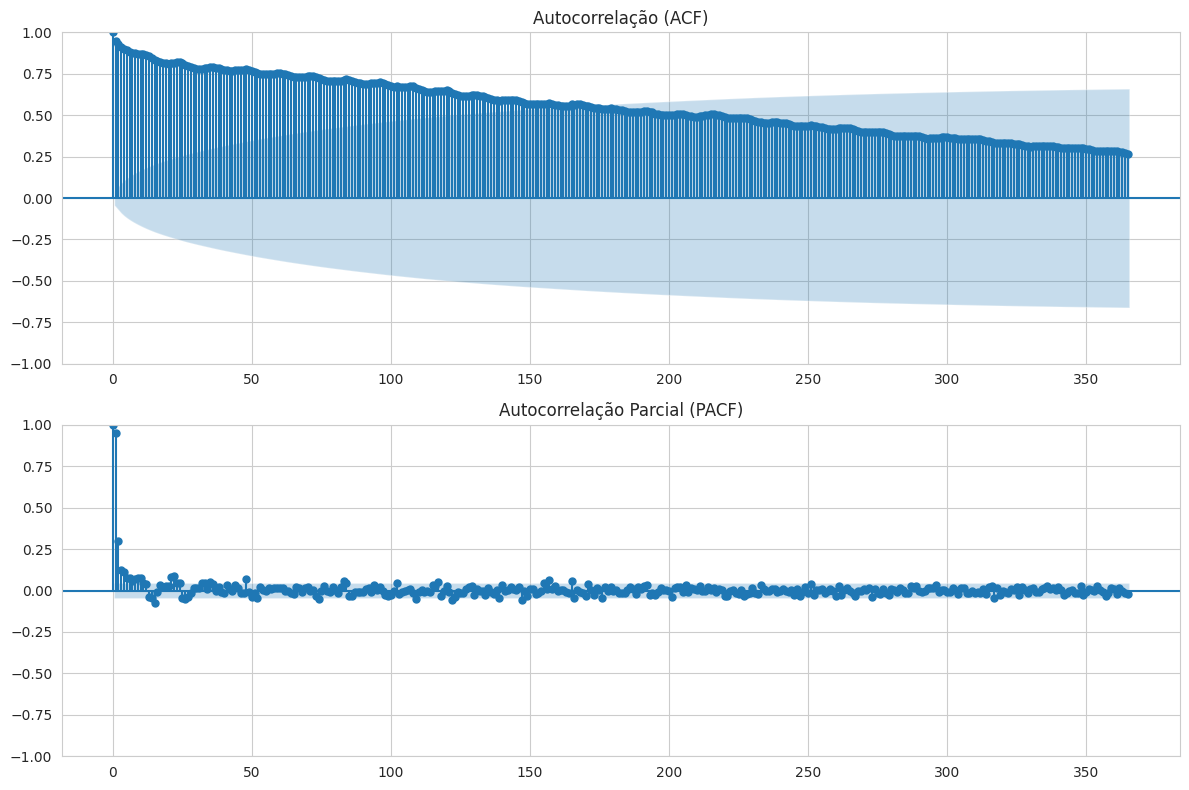

In [186]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(df['temperatura_media'], lags=365, ax=ax1)
ax1.set_title('Autocorrelação (ACF)')

plot_pacf(df['temperatura_media'], lags=365, ax=ax2)
ax2.set_title('Autocorrelação Parcial (PACF)')

plt.tight_layout()
plt.show()

## **7. Transformações da Série**

Essa etapa responde à pergunta:

* "A série precisa ser modificada antes da modelagem?"

* Nem toda série precisa de transformações.

### **7.1 Diferenciação**

Objetivo:

* remover tendência;
* tornar a série estacionária.

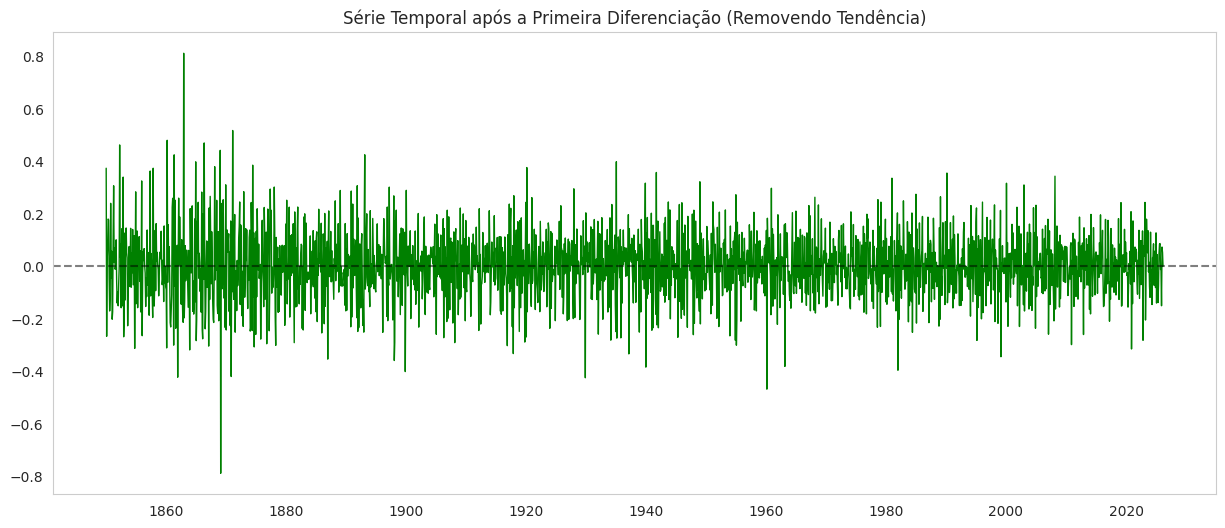

Resultado para a série diferenciada (d=1):
Resultado do Teste Dickey-Fuller:
Teste Estatístico       -1.233628e+01
p-valor                  6.262670e-23
Lags Usados              2.500000e+01
Número de Observações    2.088000e+03
Valor Crítico (1%)      -3.433486e+00
Valor Crítico (5%)      -2.862925e+00
Valor Crítico (10%)     -2.567507e+00
dtype: float64


In [187]:
# Aplicando a primeira diferenciação (d=1) para remover a tendência
df['diff_1'] = df['temperatura_media'].diff()

plt.figure(figsize=(15, 6))
plt.plot(df.index, df['diff_1'], color='green', linewidth=1)
plt.title('Série Temporal após a Primeira Diferenciação (Removendo Tendência)')
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.grid()
plt.show()

# Testando a estacionariedade na série diferenciada
print("Resultado para a série diferenciada (d=1):")
test_stationarity(df['diff_1'].dropna())

### **7.2 Transformação Logarítmica**

### **7.3 Box-Cox ou Yeo-Johnson** (Opcional)

## **Principais Modelos**

Modelos de Previsão para Séries Temporais  

├── Modelos Estatísticos Clássicos  
│     ├── Naive  
│     ├── Moving Average  
│     ├── Simple Exponential Smoothing (SES)  
│     ├── Holt  
│     ├── Holt-Winters (Exponential Smoothing)  
│     ├── AR  
│     ├── MA  
│     ├── ARMA  
│     ├── ARIMA  
│     └── SARIMA  
│  
├── Modelos Estatísticos Modernos  
│     └── Prophet  
│  
├── Machine Learning  
│     ├── Linear Regression  
│     ├── Random Forest  
│     ├── XGBoost  
│     ├── LightGBM  
│     ├── CatBoost  
│     └── SVR  
│  
└── Deep Learning  
      ├── LSTM  
      ├── GRU  
      └── Transformers  

## **8. Modelo Estatístico**

### **ExponentialSmoothing**

In [188]:
# Modelo ExponentialSmoothing
es = ExponentialSmoothing(
    df['temperatura_media'],
    seasonal_periods=12,
    trend='add',
    seasonal='add'
)

resultado = es.fit()

In [189]:
previsao = resultado.forecast(steps=48)

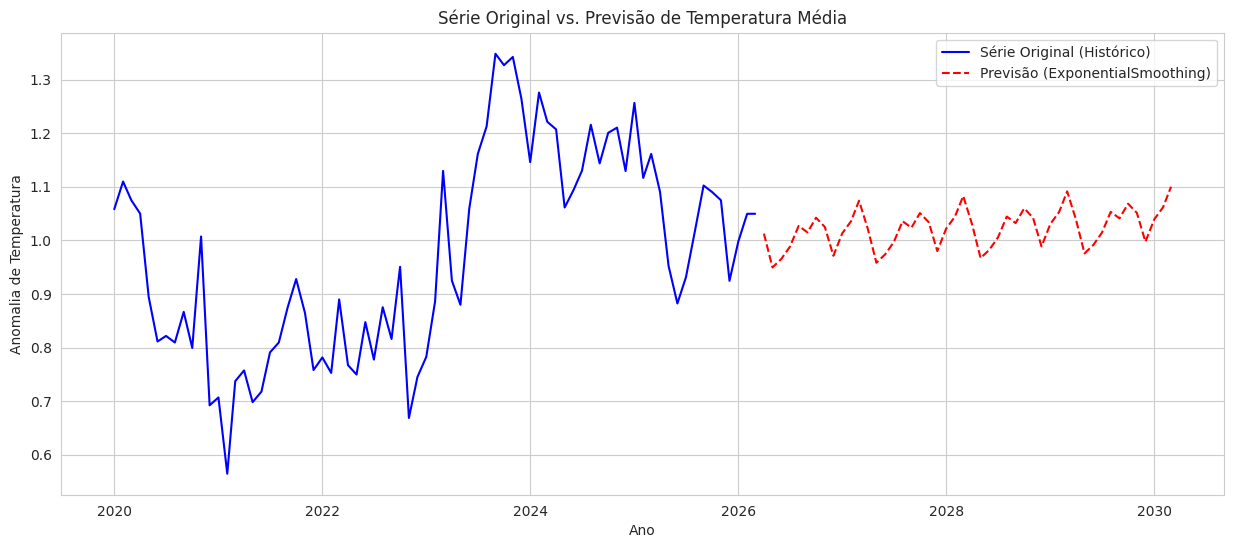

In [190]:
data_corte = df.loc['2020-01-01':]['temperatura_media']

plt.figure(figsize=(15, 6))
plt.plot(data_corte.index, data_corte, label='Série Original (Histórico)', color='blue')
plt.plot(previsao.index, previsao, label='Previsão (ExponentialSmoothing)', color='red', linestyle='--')

plt.title('Série Original vs. Previsão de Temperatura Média')
plt.xlabel('Ano')
plt.ylabel('Anomalia de Temperatura')
plt.legend()
plt.grid(True)
plt.show()

In [191]:
# Função para printar avaliação dos modelos
def avaliacao(df_test, pred):
    mae = mean_absolute_error(df_test, pred)
    rmse = np.sqrt(mean_squared_error(df_test, pred))
    mape = mean_absolute_percentage_error(df_test, pred)

    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"MAPE : {mape*100:.2f}%")

In [192]:
# ==================================================
# Separação treino e teste
# ==================================================

treino = df.iloc[:-12].drop('tendencia_12m', axis=1)
teste = df.iloc[-12:].drop('tendencia_12m', axis=1)

In [193]:
# ==================================================
# Treinamento do modelo
# ==================================================

model_es = ExponentialSmoothing(
    treino['temperatura_media'],
    trend='add',          # Tendência aditiva
    seasonal='add',       # Sazonalidade aditiva
    seasonal_periods=12   # Série mensal
)

result_es = model_es.fit()

In [194]:
# ==================================================
# Previsão
# ==================================================

pred_es = result_es.forecast(12)

In [195]:
# ==================================================
# Avaliação
# ==================================================

avaliacao(teste['temperatura_media'], pred_es)

MAE  : 0.1263
RMSE : 0.1374
MAPE : 12.88%


### **SARIMA**

In [196]:
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX

# ==================================================
# Treinamento do SARIMA
# ==================================================

model_sarimax = SARIMAX(
    treino['temperatura_media'],
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

result_sarimax = model_sarimax.fit()

In [197]:
# ==================================================
# Previsão
# ==================================================

pred_sarimax = result_sarimax.forecast(steps=12)

In [198]:
# ==================================================
# Avaliação
# ==================================================

avaliacao(teste['temperatura_media'], pred_sarimax)

MAE  : 0.1589
RMSE : 0.1683
MAPE : 16.13%


### **Auto Arima**

In [ ]:
# ==================================================
# AutoARIMA
# ==================================================

model_auto_arima = auto_arima(
    treino['temperatura_media'],
    seasonal=True,
    m=12,                    # Série mensal
    start_p=0,
    start_q=0,
    max_p=5,
    max_q=5,
    start_P=0,
    start_Q=0,
    max_P=2,
    max_Q=2,
    d=None,                  # Determina automaticamente
    D=None,                  # Determina automaticamente
    trace=True,              # Mostra as combinações testadas
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

print(model_auto_arima.summary())

In [ ]:
print(model_auto_arima.order)
print(model_auto_arima.seasonal_order)

In [ ]:
# ==================================================
# Previsão
# ==================================================

pred_auto_arima = model_auto_arima.predict(n_periods=12)

In [ ]:
# ==================================================
# Avaliação
# ==================================================

avaliacao(teste['temperatura_media'], pred_auto_arima)

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(treino.index, treino['temperatura_media'], label='Treino')
plt.plot(teste.index, teste['temperatura_media'], label='Real')
plt.plot(teste.index, pred_auto_arima, '--', label='AutoARIMA')

plt.title("Previsão com AutoARIMA")
plt.legend()
plt.grid(True)

plt.show()

### **Modelo Prophet**

In [164]:
!pip install -q prophet

In [199]:
# ==================================================
# Separação treino e teste
# ==================================================

# Para o Prophet, precisamos apenas de 'ds' e 'y'.
treino_prophet = treino.reset_index().rename(columns={'Year': 'ds', 'temperatura_media': 'y'})
teste_prophet = teste.reset_index().rename(columns={'Year': 'ds', 'temperatura_media': 'y'})

# ==================================================
# Treinamento
# ==================================================

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

prophet_model.fit(treino_prophet)

In [200]:
# ==================================================
# Previsão
# ==================================================

future_prophet = prophet_model.make_future_dataframe(periods=12, freq='MS')

forecast_prophet = prophet_model.predict(future_prophet)
pred_prophet = forecast_prophet['yhat'].tail(12).values

In [201]:
# ==================================================
# Avaliação
# ==================================================

avaliacao(teste['temperatura_media'], pred_prophet)

MAE  : 0.0692
RMSE : 0.0815
MAPE : 6.71%


#### **Gráficos**

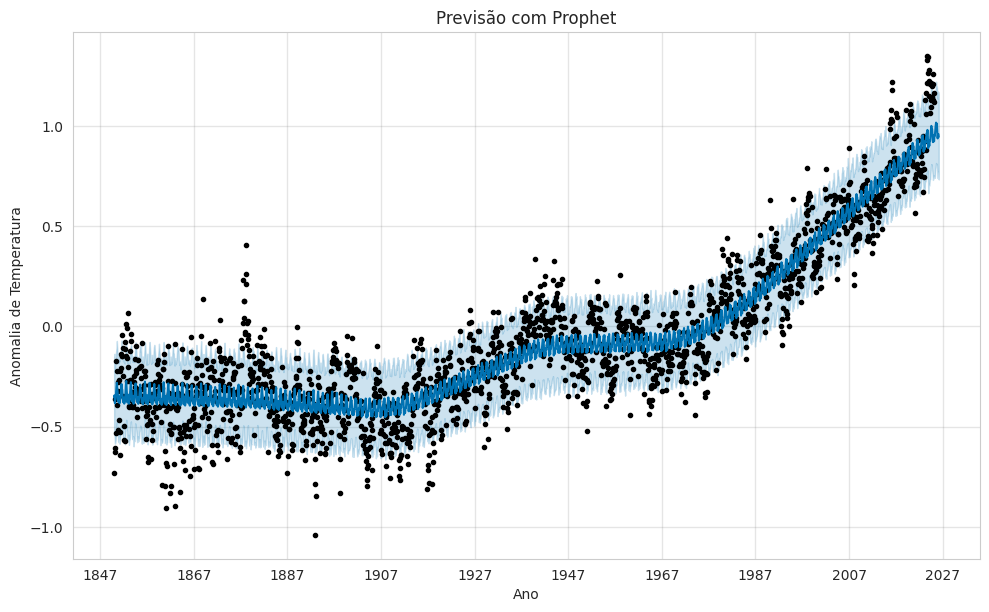

In [202]:
##
prophet_model.plot(forecast_prophet)
plt.title("Previsão com Prophet")
plt.xlabel("Ano")
plt.ylabel("Anomalia de Temperatura")
plt.show()

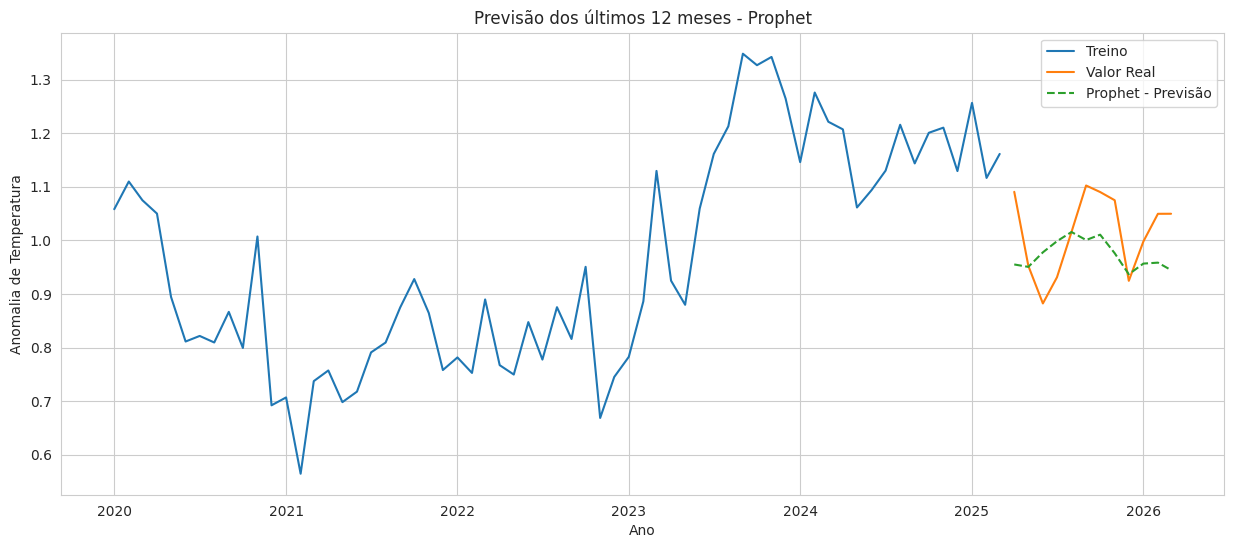

In [203]:
##
plt.figure(figsize=(15,6))

plt.plot(treino.loc['2020-01-01':].index, treino.loc['2020-01-01':]['temperatura_media'], label='Treino')
plt.plot(teste.index, teste['temperatura_media'], label='Valor Real')
plt.plot(teste.index, pred_prophet, '--', label='Prophet - Previsão')

plt.title("Previsão dos últimos 12 meses - Prophet")
plt.xlabel("Ano")
plt.ylabel("Anomalia de Temperatura")
plt.legend()
plt.grid(True)

plt.show()

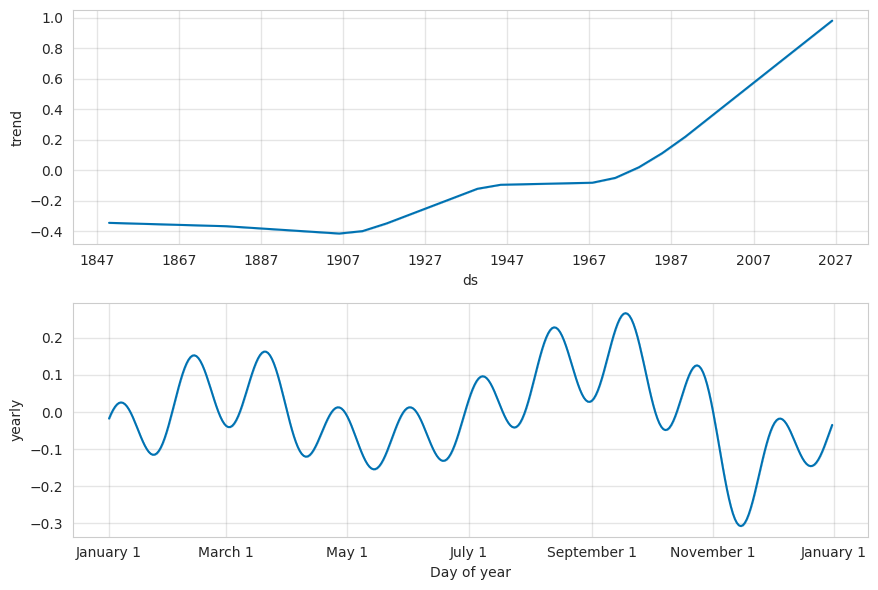

In [204]:
prophet_model.plot_components(forecast_prophet)
plt.show()

### **Resultados**

| Modelo                   |      MAE ↓ |     RMSE ↓ |     MAPE ↓ |
| ------------------------ | ---------: | ---------: | ---------: |
| 🥇 Prophet               | **0.0692** | **0.0815** |  **6.71%** |
| 🥈 Exponential Smoothing | **0.1263** | **0.1374** | **12.88%** |
| 🥉 AutoARIMA             | **0.1302** | **0.1418** | **13.30%** |
| 4º SARIMA manual         | **0.1589** | **0.1683** | **16.13%** |


### **8. Engenharia de Atributos** (Feature Engineering)

In [217]:
df_features = df.copy()
df_features.head()

,temperatura_media,tendencia_12m,diff_1
Year,,,
1850-01-01,-0.7337,NaN,NaN
1850-02-01,-0.3604,NaN,0.3733
1850-03-01,-0.6271,NaN,-0.2667
1850-04-01,-0.6053,NaN,0.0218
1850-05-01,-0.5315,NaN,0.0738


#### **8.1 Lags**

In [218]:
lags = [1, 3, 6, 12]

for lag in lags:
    df_features[f'lag_{lag}'] = df_features['temperatura_media'].shift(lag)

In [219]:
df_features.head()

,temperatura_media,tendencia_12m,diff_1,lag_1,lag_3,lag_6,lag_12
Year,,,,,,,
1850-01-01,-0.7337,NaN,NaN,NaN,NaN,NaN,NaN
1850-02-01,-0.3604,NaN,0.3733,-0.7337,NaN,NaN,NaN
1850-03-01,-0.6271,NaN,-0.2667,-0.3604,NaN,NaN,NaN
1850-04-01,-0.6053,NaN,0.0218,-0.6271,-0.7337,NaN,NaN
1850-05-01,-0.5315,NaN,0.0738,-0.6053,-0.3604,NaN,NaN


#### **8.2 Rolling Statistics**

#### **8.3 Médias Móveis**

In [220]:
df_features['rolling_mean_3'] = (df_features['temperatura_media'].rolling(3).mean().shift(1))
df_features['rolling_mean_12'] = df_features['temperatura_media'].rolling(12).mean()

df_features.head()

,temperatura_media,tendencia_12m,diff_1,lag_1,lag_3,lag_6,lag_12,rolling_mean_3,rolling_mean_12
Year,,,,,,,,,
1850-01-01,-0.7337,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1850-02-01,-0.3604,NaN,0.3733,-0.7337,NaN,NaN,NaN,NaN,NaN
1850-03-01,-0.6271,NaN,-0.2667,-0.3604,NaN,NaN,NaN,NaN,NaN
1850-04-01,-0.6053,NaN,0.0218,-0.6271,-0.7337,NaN,NaN,-0.573733,NaN
1850-05-01,-0.5315,NaN,0.0738,-0.6053,-0.3604,NaN,NaN,-0.530933,NaN


#### **8.4 Rolling Std**

In [221]:
df_features['rolling_std_12'] = df_features['temperatura_media'].rolling(12).std()

#### **8.5 Expanding Window**

In [222]:
df_features['expanding_mean'] = df_features['temperatura_media'].expanding().mean()

#### **8.6 Variáveis de Calendário**
- Dia
- Mês
- Ano
- Dia da Semana
- Final de Semana
- Feriados

In [223]:
df_features['ano'] = df.index.year
df_features['mes'] = df.index.month
df_features['trimestre'] = df.index.quarter

In [224]:
df_features.isna().sum()

,0
temperatura_media,0
tendencia_12m,11
diff_1,1
lag_1,1
lag_3,3
lag_6,6
lag_12,12
rolling_mean_3,3
rolling_mean_12,11
rolling_std_12,11


In [225]:
df_features = df_features.dropna()

In [226]:
df_features.isnull().sum()

,0
temperatura_media,0
tendencia_12m,0
diff_1,0
lag_1,0
lag_3,0
lag_6,0
lag_12,0
rolling_mean_3,0
rolling_mean_12,0
rolling_std_12,0


In [227]:
df_features.head()

,temperatura_media,tendencia_12m,diff_1,lag_1,lag_3,lag_6,lag_12,rolling_mean_3,rolling_mean_12,rolling_std_12,expanding_mean,ano,mes,trimestre
Year,,,,,,,,,,,,,,
1851-01-01,-0.2656,-0.387458,0.0568,-0.3224,-0.5162,-0.1755,-0.7337,-0.371700,-0.387458,0.149988,-0.414092,1851,1,1
1851-02-01,-0.4673,-0.396367,-0.2017,-0.2656,-0.2765,-0.2235,-0.3604,-0.288167,-0.396367,0.151402,-0.417893,1851,2,1
1851-03-01,-0.6410,-0.397525,-0.1737,-0.4673,-0.3224,-0.3938,-0.6271,-0.351767,-0.397525,0.153368,-0.432767,1851,3,1
1851-04-01,-0.5283,-0.391108,0.1127,-0.6410,-0.2656,-0.5162,-0.6053,-0.457967,-0.391108,0.145283,-0.438738,1851,4,2
1851-05-01,-0.2218,-0.365300,0.3065,-0.5283,-0.4673,-0.2765,-0.5315,-0.545533,-0.365300,0.145584,-0.425976,1851,5,2


## **10. Machine Learning**

### **9. Divisão Temporal dos Dados**
- Treino
- Validação
- Teste

In [228]:
# Separar X e y
X = df_features.drop(columns='temperatura_media')
y = df_features['temperatura_media']

# Divisão temporal
X_train_ml = X.iloc[:-12]
X_test_ml = X.iloc[-12:]

y_train_ml = y.iloc[:-12]
y_test_ml = y.iloc[-12:]

### **Feature Importance**

In [117]:
!pip install -q xgboost

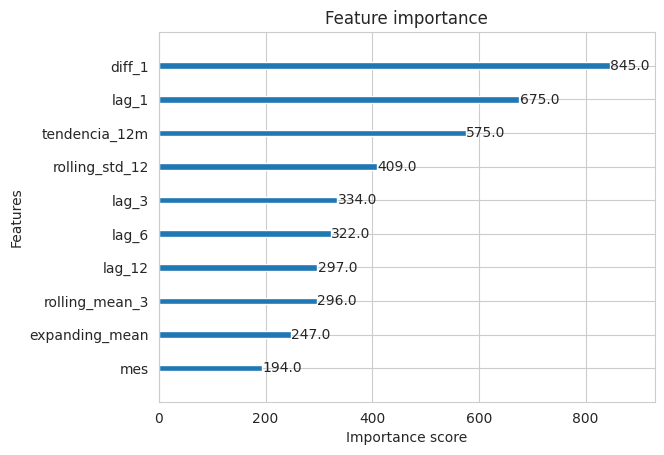

In [229]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

from xgboost import XGBRegressor

xgb = XGBRegressor()

xgb.fit(X_train_ml, y_train_ml)

plot_importance(xgb, max_num_features=10)
plt.show()

In [230]:
import pandas as pd

importancias = pd.Series(
    xgb.feature_importances_,
    index=X_train_ml.columns
).sort_values(ascending=False)

print(importancias)

rolling_mean_3     0.777707
lag_1              0.167366
diff_1             0.029232
tendencia_12m      0.023524
expanding_mean     0.000693
lag_12             0.000475
rolling_std_12     0.000358
lag_3              0.000207
ano                0.000152
lag_6              0.000145
mes                0.000141
rolling_mean_12    0.000000
trimestre          0.000000
dtype: float32


### **10. Construção do Modelo**
- Definição do algoritmo
- Ajuste dos hiperparâmetros
- Treinamento

### **XGBoost**

In [236]:
# ============================
# Modelo Simples
# ============================
# Utilização de todas as features

xgb = XGBRegressor(
    n_estimators=100,
    #learning_rate=0.05,
    #max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)

# Treinamento
xgb.fit(X_train_ml, y_train_ml)

# ============================
# Previsão
# ============================

y_pred_xgb = xgb.predict(X_test_ml)

# ============================
# Avaliação
# ============================
avaliacao(y_test_ml, y_pred_xgb)

MAE  : 0.0613
RMSE : 0.0747
MAPE : 6.26%


#### **Tunning de Hiperparametros**

In [237]:
from xgboost import XGBRegressor

from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import RandomizedSearchCV

# ================================
# Validação cruzada temporal
# ================================

tscv = TimeSeriesSplit(n_splits=5)

# ================================
# Modelo
# ================================

xgb = XGBRegressor(
    objective='reg:squarederror',
    random_state=42
)

# ================================
# Espaço de busca
# ================================

parametros = {
    "n_estimators":[100,200,300,500],
    "learning_rate":[0.01,0.03,0.05,0.1],
    "max_depth":[3,4,5,6,8],
    "subsample":[0.6,0.8,1.0],
    "colsample_bytree":[0.6,0.8,1.0],
    "min_child_weight":[1,3,5],
    "gamma":[0,0.1,0.3,0.5]
}

# ================================
# Busca
# ================================

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=parametros,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    verbose=2,
    random_state=42,
    n_jobs=-1

)

random_search.fit(X_train_ml, y_train_ml)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=True,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma...
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0],
                                        'gamma': [0, 0.1, 0.3, 0.5],
                                        'learning_rate': [0.01, 0.03, 0.05,
                                                          0.1],
                                        'max_depth': [3, 4, 5, 6, 8],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [100, 200, 300, 500],
                                        'subsample': [0.6, 0.8, 1.0]},
                   random_state=42, scoring='neg_mean_absolute_error',
                   verbose=2)

In [238]:
print(random_search.best_params_) # Melhores parametros
print(random_search.best_score_) # Melhor score

{'subsample': 0.6, 'n_estimators': 100, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 1.0}
-0.06756160077139214


#### **Predição com os melhores hiperparametros**

In [240]:
# Predição com os melhores estimadores
best_model_xgb = random_search.best_estimator_
y_pred_xgb_cv = best_model_xgb.predict(X_test_ml)

# Avaliação dos melhores parametros
avaliacao(y_test_ml, y_pred_xgb_cv)

MAE  : 0.0540
RMSE : 0.0639
MAPE : 5.46%


### **LightBoosting**

In [241]:
!pip -q install lightgbm

#### **Tunning Hiperparametros**

In [242]:
from lightgbm import LGBMRegressor

from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import RandomizedSearchCV

# ==================================
# Validação Cruzada
# ==================================

tscv = TimeSeriesSplit(n_splits=5)

# ==================================
# Modelo
# ==================================

lgbm = LGBMRegressor(
    random_state=42,
    verbose=-1
)

# ==================================
# Espaço de busca
# ==================================

parametros = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [3, 4, 5, 6, 8],
    "num_leaves": [15, 31, 63, 127],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_samples": [5, 10, 20, 30]

}

# ==================================
# Random Search
# ==================================

random_search_light = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=parametros,
    n_iter=30,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    random_state=42,
    verbose=2

)

# Treinando o modelo
random_search_light.fit(X_train_ml, y_train_ml)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
                   estimator=LGBMRegressor(random_state=42, verbose=-1),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.03, 0.05,
                                                          0.1],
                                        'max_depth': [3, 4, 5, 6, 8],
                                        'min_child_samples': [5, 10, 20, 30],
                                        'n_estimators': [100, 200, 300, 500],
                                        'num_leaves': [15, 31, 63, 127],
                                        'subsample': [0.6, 0.8, 1.0]},
                   random_state=42, scoring='neg_mean_absolute_error',
                   verbose=2)

In [261]:
print(random_search_light.best_params_)
print(random_search_light.best_score_)

{'subsample': 1.0, 'num_leaves': 127, 'n_estimators': 200, 'min_child_samples': 5, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
-0.07034651533616952


In [245]:
## Predição com o melhores parametros
best_model_light = random_search_light.best_estimator_
y_pred_light = best_model_light.predict(X_test_ml)

## Avaliação do LightBoost
avaliacao(y_test_ml, y_pred_light)

MAE  : 0.0375
RMSE : 0.0420
MAPE : 3.81%


#### **Feature Importance**

lag_1              512
diff_1             325
tendencia_12m      111
rolling_mean_3      87
rolling_std_12      56
lag_12              55
lag_3               55
lag_6               31
expanding_mean      30
ano                 22
mes                 16
trimestre            0
rolling_mean_12      0
dtype: int32


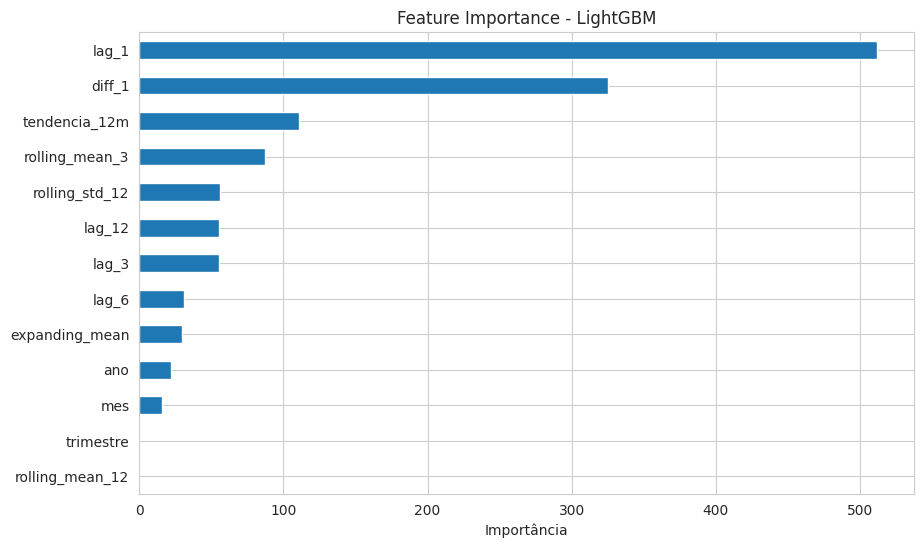

In [274]:
import pandas as pd
import matplotlib.pyplot as plt

importancias_light = pd.Series(
    best_model_light.feature_importances_,
    index=X_train_ml.columns
).sort_values(ascending=True)

print(importancias_light.sort_values(ascending=False))

plt.figure(figsize=(10,6))
importancias_light.plot(kind='barh')
plt.title("Feature Importance - LightGBM")
plt.xlabel("Importância")
plt.show()

#### **Treinando com Features mais importantes**

In [260]:
## Treinando somente com as features mais importantes
X_reduzido = df_features.drop(columns=['temperatura_media','trimestre', 'rolling_mean_12'])
y = df_features['temperatura_media']

# Divisão temporal
X_train_reduzido = X_reduzido.iloc[:-12]
X_test_reduzido = X_reduzido.iloc[-12:]

y_train_reduzido = y.iloc[:-12]
y_test_reduzido = y.iloc[-12:]

In [266]:
## Modelo LightBoost com os melhores parametros
lgbm = LGBMRegressor(**best_model_light.get_params())

## Treinando o modelo
lgbm.fit(X_train_reduzido, y_train_reduzido)

LGBMRegressor(max_depth=3, min_child_samples=5, n_estimators=200,
              num_leaves=127, random_state=42, verbose=-1)

In [267]:
## Predição com o teste
pred_lgbm = lgbm.predict(X_test_reduzido)

## Avaliação
avaliacao(y_test_reduzido, pred_lgbm)

MAE  : 0.0375
RMSE : 0.0420
MAPE : 3.81%


#### **Feature Importance**

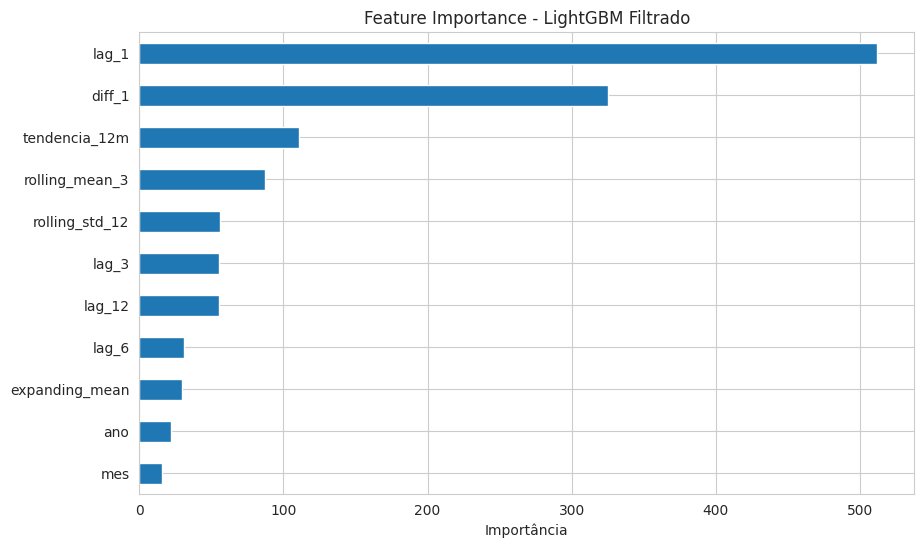

In [275]:
plt.figure(figsize=(10,6))
pd.Series(lgbm.feature_importances_, index=X_train_reduzido.columns).sort_values(ascending=True).plot(kind='barh')
plt.title("Feature Importance - LightGBM Filtrado")
plt.xlabel("Importância")
plt.show()

### **Resultados**

| Modelo                   |        MAE |       RMSE |      MAPE |
| ------------------------ | ---------: | ---------: | --------: |
| 🥇 **LightGBM (tuning)** | **0.0375** | **0.0420** | **3.81%** |
| 🥈 XGBoost (tuning)      |     0.0540 |     0.0639 |     5.46% |
| 🥉 Prophet               |     0.0692 |     0.0815 |     6.71% |
| Exponential Smoothing    |     0.1263 |     0.1374 |    12.88% |
| AutoARIMA                |     0.1302 |     0.1418 |    13.30% |
| SARIMA                   |     0.1589 |     0.1683 |    16.13% |


### **12. Diagnóstico do Modelo**

O teste de Ljung-Box é um teste estatístico usado principalmente para verificar se uma série (ou os resíduos de um modelo) possui autocorrelação significativa.
O teste de Ljung-Box verifica se os resíduos do modelo são independentes, ou seja, se ainda existe autocorrelação que o modelo não conseguiu explicar.  

Em outras palavras, ele responde à pergunta:

* "Após o treinamento do modelo, ainda existe informação temporal não capturada?"
Se a resposta for não, significa que os resíduos se comportam como ruído branco (white noise), indicando que o modelo fez um bom trabalho.

#### **12.1 Análise dos Resíduos**

#### **12.2 Verificação de Autocorrelação dos Resíduos**

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox

residuos = resultado.resid

teste = acorr_ljungbox(
    residuos,
    lags=[12],
    return_df=True
)

teste

#### **12.3 Distribuição dos Resíduos**

### **13. Previsões**

#### **13.1 Predição no Conjunto de Teste**

#### **13.2 Forecast para Períodos Futuros**

### **14. Visualização dos Resultados**

#### **14.1 Valores Reais vs Previstos**

#### **14.2 Intervalos de Confiança**

#### **14.3 Erros da Previsão**

### **15. Salvando o Modelo** (Opcional)

### **16. Conclusões**

## **11. Deep Learning**